# Cumulative Likelihood Over Time

This notebook plots the cumulative likelihood curve for one sequence within the NLL interval (numerically stable version: cumulative log-likelihood).

Notes:
- The curve starts at `t_nll_start`.
- At each event time, it accumulates `log p(\tau_i | H_{t_i^-})`.
- At the end time `t_end`, it additionally includes the terminal survival term `log S(\tau_{end})`.

In [1]:
from pathlib import Path
import contextlib
import io
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import Batch
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DEVICE = {DEVICE}')

PROJECT_ROOT = /root/autodl-tmp/em_eqf
DEVICE = cuda:0


In [16]:
# Multi-model configuration for PNR_1z comparison.
from copy import deepcopy

MODEL_SPECS = [
    {
        'label': 'ETAS+P',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'etas_20260330-231015' / 'best_model_1.pth',
    },
    {
        'label': 'ETAS+conv_mlp',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'etas_20260330-231441' / 'best_model_1.pth',
    },
    {
        'label': 'ETAS+mamba',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'etas_20260330-231612' / 'best_model_1.pth',
    },
    {
        'label': 'ETAS+mamba+gp',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'etas_20260330-232554' / 'best_model_1.pth',
    },
    {
        'label': 'RECAST+P',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'rtpp_20260402-170440' / 'best_model_1.pth',
    },
    {
        'label': 'RECAST+mamba',
        'checkpoint_path': PROJECT_ROOT / 'checkpoints' / 'rtpp_20260402-160131' / 'best_model_1.pth',
    },
]

USE_TORCH_COMPILE = False
SPLIT = 'test'   # Options: train / val / test
SEQ_INDEX = 0
STRICT_SAME_DATASET = True

# Optional override: reset t_nll_start close to zero for broader-window comparison.
RESET_T_NLL_START_NEAR_ZERO = True
OVERRIDE_T_NLL_START_VALUE = 1e-6
OVERRIDE_T_NLL_START_EPS = 1e-6

# Optional plotting mode: plot cumulative curves relative to a baseline model.
PLOT_DELTA_TO_BASELINE = True
BASELINE_MODEL_LABEL = 'ETAS+P'

# Select cumulative component to plot and validate against model NLL.
# 'time': time-only NLL; 'total': full NLL including BG/auxiliary terms.
PLOT_COMPONENT = 'total'
if PLOT_COMPONENT not in {'time', 'total'}:
    raise ValueError("PLOT_COMPONENT must be one of {'time', 'total'}.")

# Prefix micro-batch size for cumulative prefix evaluation.
# Increase for speed when memory allows; reduce when hitting OOM.
PREFIX_PARALLEL_CHUNK_SIZE = 32
if PREFIX_PARALLEL_CHUNK_SIZE < 1:
    raise ValueError('PREFIX_PARALLEL_CHUNK_SIZE must be >= 1.')

if len(MODEL_SPECS) == 0:
    raise ValueError('MODEL_SPECS is empty. Please provide at least one checkpoint.')

loaded_models = []
for spec in MODEL_SPECS:
    label = spec['label']
    checkpoint_path = Path(spec['checkpoint_path'])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found for {label}: {checkpoint_path}')

    model, args = load_and_prepare_model(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        compile=USE_TORCH_COMPILE,
    )
    loaded_models.append({
        'label': label,
        'checkpoint_path': checkpoint_path,
        'model': model,
        'args': args,
    })

# Use the first model's dataset to define the evaluation sequence for all comparisons.
base_args = loaded_models[0]['args']
catalog_ds, registry_name, _ = load_tpp_catalog(
    base_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / base_args.dataset,
    catalog_cfg=getattr(base_args, 'catalog_cfg', {}),
)

split_map = {
    'train': catalog_ds.train,
    'val': catalog_ds.val,
    'test': catalog_ds.test,
}
if SPLIT not in split_map:
    raise ValueError(f'Unsupported SPLIT={SPLIT}. Choose from train/val/test.')

seqs = split_map[SPLIT]
if SEQ_INDEX < 0 or SEQ_INDEX >= len(seqs):
    raise IndexError(f'SEQ_INDEX={SEQ_INDEX} out of range for split={SPLIT} (len={len(seqs)}).')

seq = seqs[SEQ_INDEX]
if RESET_T_NLL_START_NEAR_ZERO:
    seq = deepcopy(seq)
    old_t_nll_start = float(seq.t_nll_start)

    if OVERRIDE_T_NLL_START_VALUE is None:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    else:
        target_t_nll_start = float(OVERRIDE_T_NLL_START_VALUE)

    # Keep the same boundary convention used across NLL logic: t_start < t_nll_start <= t_end.
    if target_t_nll_start <= seq.t_start:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    if target_t_nll_start > seq.t_end:
        raise ValueError(
            f'OVERRIDE_T_NLL_START_VALUE={target_t_nll_start} exceeds t_end={seq.t_end}.'
        )

    seq.t_nll_start = target_t_nll_start
    print(f'Override t_nll_start: {old_t_nll_start:.6f} -> {seq.t_nll_start:.6f}')

# Enforce same-dataset comparisons by default to keep curves comparable.
if STRICT_SAME_DATASET:
    for item in loaded_models:
        if item['args'].dataset != base_args.dataset:
            raise ValueError(
                'All compared models must share the same dataset when STRICT_SAME_DATASET=True. '
                f"Found {item['label']} dataset={item['args'].dataset} vs base={base_args.dataset}."
            )

print(f'Evaluation catalog registry: {registry_name}')
print(f'Sequence split={SPLIT}, index={SEQ_INDEX}, num_events={len(seq)}')
print(f't_start={seq.t_start:.6f}, t_nll_start={seq.t_nll_start:.6f}, t_end={seq.t_end:.6f}')
print(f'Prefix chunk size: {PREFIX_PARALLEL_CHUNK_SIZE}')
print('--- Models ---')
for item in loaded_models:
    print(
        f"[{item['label']}] model={item['args'].model}, dataset={item['args'].dataset}, "
        f"checkpoint={item['checkpoint_path']}"
    )

Override t_nll_start: 59.666667 -> 0.000001
Evaluation catalog registry: PNR_1z-Standard
Sequence split=test, index=0, num_events=6140
t_start=0.000000, t_nll_start=0.000001, t_end=64.208328
Prefix chunk size: 32
--- Models ---
[ETAS+P] model=etas, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-231015/best_model_1.pth
[ETAS+conv_mlp] model=etas, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-231441/best_model_1.pth
[ETAS+mamba] model=etas, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-231612/best_model_1.pth
[ETAS+mamba+gp] model=etas, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/etas_20260330-232554/best_model_1.pth
[RECAST+P] model=rtpp, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/rtpp_20260402-170440/best_model_1.pth
[RECAST+mamba] model=rtpp, dataset=PNR_1z, checkpoint=/root/autodl-tmp/em_eqf/checkpoints/rtpp_20260402-160131/best_model_1.pth


In [17]:
def _build_nll_kwargs(model):
    import inspect

    sig = inspect.signature(model.nll_loss).parameters
    kwargs = {}
    if 'reduction' in sig:
        kwargs['reduction'] = 'none'
    if 'return_dict' in sig:
        kwargs['return_dict'] = True
    if 'use_b_updater' in sig:
        kwargs['use_b_updater'] = False
    return kwargs


def _extract_time_total_from_out(out):
    if isinstance(out, dict):
        time_val = out.get('time', out.get('total'))
        total_val = out.get('total', time_val)
        return time_val, total_val
    return out, out


def _model_nll_values_batch(model, sequences, device=None):
    if len(sequences) == 0:
        return [], []

    if device is None:
        device = next(model.parameters()).device

    batch = Batch.from_list(sequences).to(device)
    kwargs = _build_nll_kwargs(model)

    with torch.inference_mode(), contextlib.redirect_stdout(io.StringIO()):
        out = model.nll_loss(batch, **kwargs)

    time_val, total_val = _extract_time_total_from_out(out)
    time_tensor = torch.as_tensor(time_val).reshape(-1)
    total_tensor = torch.as_tensor(total_val).reshape(-1)

    expected = len(sequences)
    if time_tensor.numel() != expected or total_tensor.numel() != expected:
        raise RuntimeError(
            f'Unexpected nll shape for batched prefixes: '
            f'time={tuple(time_tensor.shape)}, total={tuple(total_tensor.shape)}, expected={expected}'
        )

    time_list = time_tensor.detach().cpu().to(torch.float64).tolist()
    total_list = total_tensor.detach().cpu().to(torch.float64).tolist()
    return time_list, total_list


def _model_nll_values(model, sequence, device=None):
    time_list, total_list = _model_nll_values_batch(model, [sequence], device=device)
    return float(time_list[0]), float(total_list[0])


def _cumulative_curve_recurrent_fast(model, sequence, device=None, eps=1e-10):
    """
    Fast cumulative log-likelihood curve for recurrent-style TPP models.

    This matches the decomposition used by recurrent model.nll_loss:
    event log-pdf terms + optional start correction + terminal survival.

    Note: this fast path tracks the time component decomposition.
    """
    if device is None:
        device = next(model.parameters()).device

    batch = Batch.from_list([sequence]).to(device)

    with torch.inference_mode():
        context = model.get_context(batch)

        with contextlib.redirect_stdout(io.StringIO()):
            inter_time_dist = model.get_inter_time_dist(context)

        log_pdf = inter_time_dist.log_prob(batch.inter_times.clamp_min(eps))[0]
        nll_mask = batch.nll_event_mask[0].bool()

        event_times = batch.arrival_times[0][nll_mask]
        event_log_like = log_pdf[nll_mask]
        cum_event_log_like = torch.cumsum(event_log_like, dim=0)

        arange = torch.arange(batch.batch_size, device=device)

        last_surv_context = context[arange, batch.end_idx, :]
        with contextlib.redirect_stdout(io.StringIO()):
            last_surv_dist = model.get_inter_time_dist(last_surv_context)
        last_surv_val = last_surv_dist.log_survival(batch.inter_times[arange, batch.end_idx].clamp_min(eps))
        last_log_surv = last_surv_val.reshape(-1)[0]

        offset_log_like = torch.tensor(0.0, device=device)
        if torch.any(batch.t_nll_start != batch.t_start):
            prev_surv_context = context[arange, batch.start_idx, :]
            with contextlib.redirect_stdout(io.StringIO()):
                prev_surv_dist = model.get_inter_time_dist(prev_surv_context)
            prev_surv_time = batch.inter_times[arange, batch.start_idx] - (
                batch.arrival_times[arange, batch.start_idx] - batch.t_nll_start
            )
            prev_surv_val = prev_surv_dist.log_survival(prev_surv_time.clamp_min(eps))
            prev_log_surv = prev_surv_val.reshape(-1)[0]
            offset_log_like = -prev_log_surv

        total_log_like = offset_log_like + event_log_like.sum() + last_log_surv

    t0 = float(batch.t_nll_start[0].detach().cpu().item())
    t_end = float(batch.t_end[0].detach().cpu().item())

    times = [t0]
    cum_ll = [float(offset_log_like.detach().cpu().item())]

    event_times_np = event_times.detach().cpu().numpy()
    cum_event_np = (offset_log_like + cum_event_log_like).detach().cpu().numpy()

    for t, val in zip(event_times_np, cum_event_np):
        times.append(float(t))
        cum_ll.append(float(val))

    times.append(t_end)
    cum_ll.append(float(total_log_like.detach().cpu().item()))

    out = {
        'time': np.asarray(times, dtype=float),
        'cum_log_likelihood': np.asarray(cum_ll, dtype=float),
    }
    out['cum_nll'] = -out['cum_log_likelihood']

    meta = {
        'num_events_in_nll': int(nll_mask.sum().item()),
        'offset_log_likelihood': float(offset_log_like.detach().cpu().item()),
        'terminal_log_survival': float(last_log_surv.detach().cpu().item()),
        'final_log_likelihood': float(total_log_like.detach().cpu().item()),
        'curve_method': 'recurrent_fast',
    }

    return out, meta


def _cumulative_curve_prefix_generic(model, sequence, device=None, prefix_chunk_size=None):
    """
    Generic cumulative curve for models without get_context/get_inter_time_dist.

    It evaluates model.nll_loss on prefixes [t_start, t_cur] for each event time.
    Prefixes are evaluated in micro-batches to improve throughput.
    """
    if device is None:
        device = next(model.parameters()).device

    chunk_size = PREFIX_PARALLEL_CHUNK_SIZE if prefix_chunk_size is None else int(prefix_chunk_size)
    chunk_size = max(1, chunk_size)

    event_times = sequence.arrival_times
    nll_event_times = event_times[(event_times > sequence.t_nll_start) & (event_times <= sequence.t_end)]

    eval_times = [float(sequence.t_nll_start)]
    eval_times.extend(float(t) for t in nll_event_times.detach().cpu().tolist())

    t_end = float(sequence.t_end)
    if eval_times[-1] < t_end:
        eval_times.append(t_end)

    seq_t_start = float(sequence.t_start)
    seq_t_nll_start = float(sequence.t_nll_start)
    seq_t_end = float(sequence.t_end)

    min_prefix_span = 1e-6
    min_end_required = seq_t_nll_start + min_prefix_span
    if hasattr(sequence, 'time_series_times') and sequence.time_series_times is not None:
        ts_times = torch.as_tensor(sequence.time_series_times)
        if ts_times.numel() >= 2:
            # BG interpolation expects at least two time samples.
            min_end_required = max(min_end_required, float(ts_times[1].detach().cpu().item()) + 1e-12)

    end_eval_values = []
    for t_cur in eval_times:
        end_eval = float(t_cur)
        # Guard against float32 round-off near zero that can make end < t_nll_start.
        if end_eval <= seq_t_nll_start:
            end_eval = min(seq_t_end, min_end_required)
        end_eval = max(end_eval, min_end_required)
        end_eval = max(end_eval, seq_t_start)
        end_eval = min(end_eval, seq_t_end)
        end_eval_values.append(end_eval)

    cum_ll_time = []
    cum_ll_total = []

    idx = 0
    while idx < len(end_eval_values):
        cur_chunk = min(chunk_size, len(end_eval_values) - idx)
        end_chunk = end_eval_values[idx: idx + cur_chunk]
        seq_chunk = [
            sequence.get_subsequence(start=seq_t_start, end=end_eval)
            for end_eval in end_chunk
        ]

        try:
            nll_time_chunk, nll_total_chunk = _model_nll_values_batch(model, seq_chunk, device=device)
        except RuntimeError as exc:
            is_oom = 'out of memory' in str(exc).lower()
            if is_oom and cur_chunk > 1:
                chunk_size = max(1, cur_chunk // 2)
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                continue
            raise

        cum_ll_time.extend([-float(v) for v in nll_time_chunk])
        cum_ll_total.extend([-float(v) for v in nll_total_chunk])
        idx += cur_chunk

    out = {
        'time': np.asarray(eval_times, dtype=float),
        'cum_log_likelihood': np.asarray(cum_ll_time, dtype=float),
        'cum_log_likelihood_time': np.asarray(cum_ll_time, dtype=float),
        'cum_log_likelihood_total': np.asarray(cum_ll_total, dtype=float),
    }
    out['cum_nll'] = -out['cum_log_likelihood']
    out['cum_nll_time'] = -out['cum_log_likelihood_time']
    out['cum_nll_total'] = -out['cum_log_likelihood_total']

    meta = {
        'num_events_in_nll': int(nll_event_times.numel()),
        'final_log_likelihood': float(cum_ll_time[-1]),
        'final_log_likelihood_total': float(cum_ll_total[-1]),
        'curve_method': 'prefix_nll',
        'prefix_chunk_size': int(chunk_size),
        'num_prefix_evals': int(len(eval_times)),
    }
    return out, meta


def cumulative_log_likelihood_curve(
    model,
    sequence,
    device=None,
    eps=1e-10,
    component='time',
    prefix_chunk_size=None,
):
    if component not in {'time', 'total'}:
        raise ValueError("component must be one of {'time', 'total'}.")

    # Total component may include BG/auxiliary terms, so use the generic prefix evaluation.
    if component == 'total':
        return _cumulative_curve_prefix_generic(
            model,
            sequence,
            device=device,
            prefix_chunk_size=prefix_chunk_size,
        )

    if hasattr(model, 'get_context') and hasattr(model, 'get_inter_time_dist'):
        return _cumulative_curve_recurrent_fast(model, sequence, device=device, eps=eps)
    return _cumulative_curve_prefix_generic(
        model,
        sequence,
        device=device,
        prefix_chunk_size=prefix_chunk_size,
    )


def reference_nll_from_model(model, sequence, device=None):
    return _model_nll_values(model, sequence, device=device)

In [18]:
model_results = []

if PLOT_COMPONENT == 'total':
    DEFAULT_CURVE_KEY = 'cum_log_likelihood_total'
    NLL_COMPONENT_LABEL = 'total'
else:
    DEFAULT_CURVE_KEY = 'cum_log_likelihood'
    NLL_COMPONENT_LABEL = 'time'

for item in loaded_models:
    label = item['label']
    model = item['model']

    curve, meta = cumulative_log_likelihood_curve(
        model,
        seq,
        device=DEVICE,
        component=PLOT_COMPONENT,
        prefix_chunk_size=PREFIX_PARALLEL_CHUNK_SIZE,
    )
    nll_time_ref, nll_total_ref = reference_nll_from_model(model, seq, device=DEVICE)

    final_log_likelihood_time = float(meta['final_log_likelihood'])
    final_log_likelihood_total = float(meta.get('final_log_likelihood_total', final_log_likelihood_time))

    if PLOT_COMPONENT == 'total':
        final_log_likelihood_selected = final_log_likelihood_total
        nll_ref_selected = nll_total_ref
    else:
        final_log_likelihood_selected = final_log_likelihood_time
        nll_ref_selected = nll_time_ref

    computed_nll_selected = -final_log_likelihood_selected
    abs_diff = abs(computed_nll_selected - nll_ref_selected)

    model_results.append({
        'label': label,
        'curve': curve,
        'meta': meta,
        'nll_time_ref': nll_time_ref,
        'nll_total_ref': nll_total_ref,
        'nll_ref_selected': nll_ref_selected,
        'final_log_likelihood_time': final_log_likelihood_time,
        'final_log_likelihood_total': final_log_likelihood_total,
        'final_log_likelihood_selected': final_log_likelihood_selected,
        'computed_nll_selected': computed_nll_selected,
        'abs_diff': abs_diff,
        'model_name': item['args'].model,
        'dataset': item['args'].dataset,
        'checkpoint_path': str(item['checkpoint_path']),
    })

# Plot metadata and optional baseline-delta transformation.
PLOT_CURVE_KEY = DEFAULT_CURVE_KEY
PLOT_CURVE_YLABEL = f'Cumulative log-likelihood ({NLL_COMPONENT_LABEL})'
PLOT_TITLE = f'Cumulative log-likelihood over time comparison ({NLL_COMPONENT_LABEL}, {SPLIT}[{SEQ_INDEX}])'

for res in model_results:
    res['curve']['time_plot'] = np.asarray(res['curve']['time'], dtype=float)
    res['curve']['cum_log_likelihood_on_plot'] = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)
    res['curve']['cum_nll_on_plot'] = -res['curve']['cum_log_likelihood_on_plot']

if PLOT_DELTA_TO_BASELINE:
    label_to_result = {res['label']: res for res in model_results}
    if BASELINE_MODEL_LABEL not in label_to_result:
        raise ValueError(
            f'BASELINE_MODEL_LABEL={BASELINE_MODEL_LABEL} not found in model labels: {list(label_to_result.keys())}'
        )

    baseline_res = label_to_result[BASELINE_MODEL_LABEL]
    baseline_time = np.asarray(baseline_res['curve']['time'], dtype=float)
    baseline_ll = np.asarray(baseline_res['curve'][DEFAULT_CURVE_KEY], dtype=float)

    for res in model_results:
        t = np.asarray(res['curve']['time'], dtype=float)
        ll = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)

        if t.shape == baseline_time.shape and np.allclose(t, baseline_time, rtol=0.0, atol=1e-10):
            ll_on_baseline_time = ll
        else:
            # Align with right-continuous step convention used in plt.step(..., where='post').
            idx = np.searchsorted(t, baseline_time, side='right') - 1
            idx = np.clip(idx, 0, len(t) - 1)
            ll_on_baseline_time = ll[idx]

        delta_ll = ll_on_baseline_time - baseline_ll
        res['curve']['time_plot'] = baseline_time
        res['curve']['cum_log_likelihood_on_plot'] = ll_on_baseline_time
        res['curve']['cum_nll_on_plot'] = -ll_on_baseline_time
        res['curve']['cum_log_likelihood_delta'] = delta_ll

    PLOT_CURVE_KEY = 'cum_log_likelihood_delta'
    PLOT_CURVE_YLABEL = (
        f'Cumulative log-likelihood difference vs baseline ({BASELINE_MODEL_LABEL}, {NLL_COMPONENT_LABEL})'
    )
    PLOT_TITLE = f'Cumulative log-likelihood delta over time ({NLL_COMPONENT_LABEL}, {SPLIT}[{SEQ_INDEX}])'
    print(f'Using baseline model for delta plot: {BASELINE_MODEL_LABEL}')

print('--- Comparison Summary ---')
for res in model_results:
    print(f"[{res['label']}] model={res['model_name']} | dataset={res['dataset']}")
    print(f"  NLL events in window: {res['meta']['num_events_in_nll']}")
    print(
        f"  Final cumulative log-likelihood ({NLL_COMPONENT_LABEL}): "
        f"{res['final_log_likelihood_selected']:.8f}"
    )
    print(f"  Computed {NLL_COMPONENT_LABEL} NLL = {res['computed_nll_selected']:.8f}")
    print(f"  Model {NLL_COMPONENT_LABEL} NLL    = {res['nll_ref_selected']:.8f}")
    print(f"  Absolute diff      = {res['abs_diff']:.8e}")
    print(f"  Model time NLL     = {res['nll_time_ref']:.8f}")
    print(f"  Model total NLL    = {res['nll_total_ref']:.8f}")
    if PLOT_DELTA_TO_BASELINE:
        final_delta = float(res['curve']['cum_log_likelihood_delta'][-1])
        print(f"  Final delta vs baseline = {final_delta:.8f}")
    print('')

Using baseline model for delta plot: ETAS+P
--- Comparison Summary ---
[ETAS+P] model=etas | dataset=PNR_1z
  NLL events in window: 6140
  Final cumulative log-likelihood (total): 37973.00390625
  Computed total NLL = -37973.00390625
  Model total NLL    = -37973.00390625
  Absolute diff      = 0.00000000e+00
  Model time NLL     = -37973.00390625
  Model total NLL    = -37973.00390625
  Final delta vs baseline = 0.00000000

[ETAS+conv_mlp] model=etas | dataset=PNR_1z
  NLL events in window: 6140
  Final cumulative log-likelihood (total): 37909.00390625
  Computed total NLL = -37909.00390625
  Model total NLL    = -37909.00781250
  Absolute diff      = 3.90625000e-03
  Model time NLL     = -37909.00781250
  Model total NLL    = -37909.00781250
  Final delta vs baseline = -64.00000000

[ETAS+mamba] model=etas | dataset=PNR_1z
  NLL events in window: 6140
  Final cumulative log-likelihood (total): 38052.92578125
  Computed total NLL = -38052.92578125
  Model total NLL    = -38052.9296875

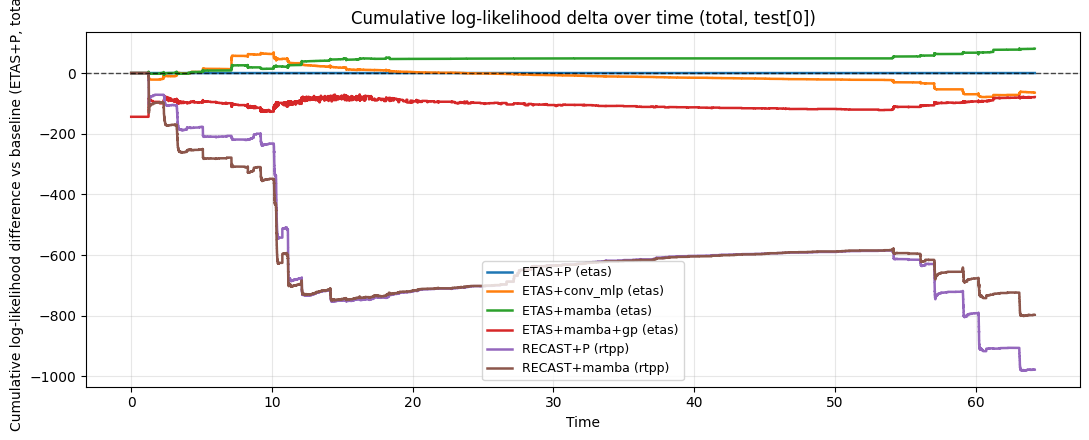

In [19]:
plt.figure(figsize=(11, 4.5))

for res in model_results:
    t = res['curve']['time_plot']
    y = res['curve'][PLOT_CURVE_KEY]
    plt.step(t, y, where='post', linewidth=1.8, label=f"{res['label']} ({res['model_name']})")

if PLOT_DELTA_TO_BASELINE:
    plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)

plt.xlabel('Time')
plt.ylabel(PLOT_CURVE_YLABEL)
plt.title(PLOT_TITLE)
plt.grid(alpha=0.3)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import csv

# Export multi-model comparison outputs.
out_dir = PROJECT_ROOT / 'notebooks' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

fig_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}.png'
curve_csv_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_curves.csv'
summary_csv_path = out_dir / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_summary.csv'

# 1) Save comparison plot
plt.figure(figsize=(11, 4.5))
for res in model_results:
    t = res['curve']['time_plot']
    y = res['curve'][PLOT_CURVE_KEY]
    plt.step(t, y, where='post', linewidth=1.8, label=f"{res['label']} ({res['model_name']})")
if PLOT_DELTA_TO_BASELINE:
    plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlabel('Time')
plt.ylabel(PLOT_CURVE_YLABEL)
plt.title(PLOT_TITLE)
plt.grid(alpha=0.3)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(fig_path, dpi=160)
plt.close()

# 2) Save long-format curve data (includes plotted value and optional delta).
with open(curve_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'time',
        'cum_log_likelihood_on_plot', 'cum_nll_on_plot',
        'cum_log_likelihood_delta', 'plot_value', 'plot_key'
    ])
    for res in model_results:
        label = res['label']
        model_name = res['model_name']
        dataset = res['dataset']
        curve = res['curve']

        t_plot = curve['time_plot']
        ll_on_plot = curve['cum_log_likelihood_on_plot']
        nll_on_plot = curve['cum_nll_on_plot']
        delta_curve = curve.get('cum_log_likelihood_delta', np.full_like(ll_on_plot, np.nan))
        plot_values = curve[PLOT_CURVE_KEY]

        for t, ll, nll, dlt, p in zip(t_plot, ll_on_plot, nll_on_plot, delta_curve, plot_values):
            writer.writerow([
                label,
                model_name,
                dataset,
                float(t),
                float(ll),
                float(nll),
                float(dlt) if np.isfinite(dlt) else '',
                float(p),
                PLOT_CURVE_KEY,
            ])

# 3) Save summary data
with open(summary_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'checkpoint_path',
        'num_events_in_nll', 'selected_component', 'final_log_likelihood_selected',
        'computed_selected_nll', 'model_selected_nll',
        'model_time_nll', 'model_total_nll', 'abs_diff',
        'final_delta_vs_baseline'
    ])
    for res in model_results:
        final_delta = (
            float(res['curve']['cum_log_likelihood_delta'][-1])
            if 'cum_log_likelihood_delta' in res['curve']
            else ''
        )
        writer.writerow([
            res['label'],
            res['model_name'],
            res['dataset'],
            res['checkpoint_path'],
            int(res['meta']['num_events_in_nll']),
            NLL_COMPONENT_LABEL,
            float(res['final_log_likelihood_selected']),
            float(res['computed_nll_selected']),
            float(res['nll_ref_selected']),
            float(res['nll_time_ref']),
            float(res['nll_total_ref']),
            float(res['abs_diff']),
            final_delta,
        ])

print(f'Saved comparison plot : {fig_path}')
print(f'Saved curves CSV      : {curve_csv_path}')
print(f'Saved summary CSV     : {summary_csv_path}')

Saved comparison plot : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_PNR_1z_test_0.png
Saved curves CSV      : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_PNR_1z_test_0_curves.csv
Saved summary CSV     : /root/autodl-tmp/em_eqf/notebooks/outputs/cum_log_likelihood_compare_PNR_1z_test_0_summary.csv
